[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dragomier/Machine_Learning_2026/blob/main/Homework8.ipynb)

In [31]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Fix the random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define ellipse parameters
focus1 = torch.tensor([-2.0, 0.0])  # First focus
focus2 = torch.tensor([2.0, 0.0])   # Second focus
constant_sum = 6.0  # The sum of distances to the two foci

# Initialize random 2D points from uniform distribution
num_points = 100
points = torch.rand((num_points, 2)) * 10 - 5  # Uniformly distributed in [-5, 5]
points.requires_grad = True

# Reset trajectories
trajectories = [[] for _ in range(num_points)]
loss_history = []


In [32]:
def plot_results(epoch, trajectories, loss_history=None):
    if loss_history is not None:
      fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    else:
      fig, axes = plt.subplots(1, 1, figsize=(6, 6))
      axes = [axes]
    points = np.array([trajectories[i][-1] for i in range(num_points)])
    # Left plot: Scatter of points with trajectories
    axes[0].scatter(points[:, 0], points[:, 1], label=f'Points - Epoch {epoch}')
    f1 = focus1.detach().cpu().numpy()
    f2 = focus2.detach().cpu().numpy()
    axes[0].scatter([f1[0], f2[0]], [f1[1], f2[1]], color='red', marker='x', s=100, label='Foci')

    # Draw movement traces
    for i in range(num_points):
        trajectory = np.array(trajectories[i])
        axes[0].plot(trajectory[:, 0], trajectory[:, 1], color='gray', linestyle='-', linewidth=0.5)

    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].legend()


    axes[0].grid()

    if loss_history is not None:
      axes[0].set_title(f'Points after Epoch {epoch}')
      # Right plot: Loss history
      axes[1].plot(loss_history, color='blue')
      axes[1].set_xlabel("Epoch")
      axes[1].set_ylabel("Loss")
      axes[1].set_title("Loss Convergence")
      axes[1].grid()
    else:
      axes[0].set_title(f'Points before Epoch {epoch}')


In [33]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
%matplotlib inline

def train_points(loss_fun, num_epochs, learning_rate):
    optimizer = torch.optim.Adam([points], lr=learning_rate)
    trajectories = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        loss = loss_fun(points, focus1, focus2)
        loss.backward()
        optimizer.step()

        trajectories.append(points.detach().cpu().clone())

    return trajectories

def make_animation_for_loss(loss, num_epochs, learning_rate):
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    scatter1 = ax.scatter(points[:, 0].detach().cpu().numpy(), points[:, 1].detach().cpu().numpy(), label=f'Points - Epoch {0}')

    f1 = focus1.detach().cpu().numpy()
    f2 = focus2.detach().cpu().numpy()
    scatter2 = ax.scatter([f1[0], f2[0]], [f1[1], f2[1]], color='red', marker='x', s=100, label='Foci')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()

    data_points = train_points(loss, num_epochs, learning_rate)

    def update(frame):
        scatter1.set_offsets(data_points[10*frame].detach().cpu().numpy())
        return scatter1
    anim = FuncAnimation(fig, update, frames=num_epochs//10, interval=100)
    display(HTML(anim.to_jshtml()))

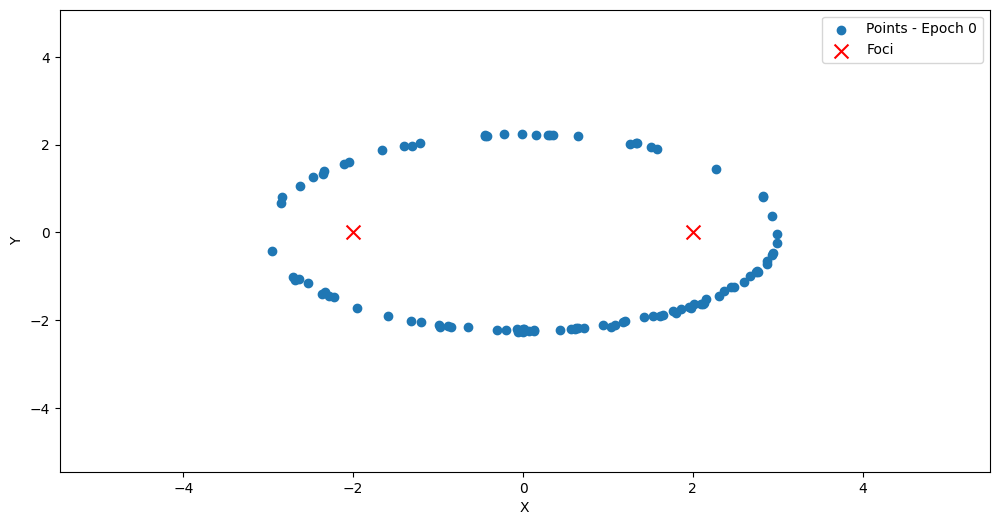

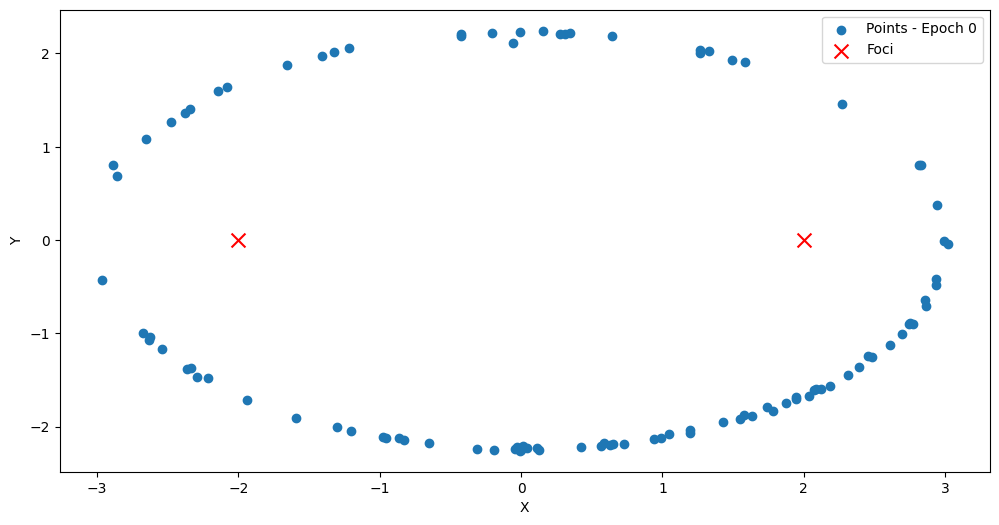

In [34]:
num_epochs = 100
learning_rate = 0.1

loss_0 = lambda points, focus1, focus2: torch.mean(
    torch.mean(torch.where(torch.norm(points - focus1, dim=1) +
              torch.norm(points - focus2, dim=1) - constant_sum == 0, 0, 1))
)
#make_animation_for_loss(loss_0, num_epochs, learning_rate)

loss_1 = lambda points, focus1, focus2: torch.mean(
    torch.abs(torch.norm(points - focus1, dim=1) +
              torch.norm(points - focus2, dim=1) - constant_sum)
)
make_animation_for_loss(loss_1, num_epochs, learning_rate)

loss_inf = lambda points, focus1, focus2: torch.max(
    torch.abs(torch.norm(points - focus1, dim=1) +
              torch.norm(points - focus2, dim=1) - constant_sum)
)
make_animation_for_loss(loss_inf, num_epochs, learning_rate)

# Conclusion